# Model híbrid: fusió de dades tabulars i àudio

Revisió del bloc híbrid que afegeix una **segona variant de fusió *late*** —la fusió per
**probabilitats calibrades**— al costat de la fusió per **rang**, per resoldre la limitació de
transductivitat d'aquesta darrera. La resta del protocol és idèntica als blocs 06 i 07.

L'objectiu segueix sent combinar les dues fonts a nivell d'infant:

- les **22 característiques tabulars**, sobre les quals el millor model del bloc 06 va ser una
  **Regressió Logística** (`StandardScaler` + `LogisticRegression`, C=0.01, L2),
  desada a `outputs/tabular_model.pkl`;
- les **mostres d'àudio**, resumides per infant en un *embedding* de **WavLM-base** (768 dim)
  amb *mean-pool*, sobre el qual el millor model del bloc 07 va ser un **linear probe**
  (`StandardScaler` + `LogisticRegression`, C=0.1), desat a `outputs/final_model.joblib`.

### Estratègies de fusió comparades
1. **Només tabular** / **Només àudio** — baselines d'una sola modalitat.
2. **Fusió *early* (concatenació)** — un únic classificador sobre els dos vectors units.
3. **Fusió *late* (rang)** — mitjana dels **rangs percentils** de les dues probabilitats. Resol
   la no-comparabilitat de les escales (~0.43 vs ~0.12) però és **transductiva**: el rang d'un
   infant depèn de la composició del lot que es puntua i el llindar no és transferible cas a cas.
4. **Fusió *late* (calibrada)** — cada model base es **calibra** a probabilitats comparables
   (sigmoide/Platt amb CV interna, sense fuita) i se'n **promitgen les probabilitats calibrades**.
   A diferència del rang, **no és transductiva**: cada model calibrat és una funció fixa, de
   manera que la predicció d'un infant no depèn de la resta del lot i el model és **desplegable
   subjecte a subjecte**.
5. **Fusió *late* (*stacking*)** — un meta-classificador aprèn a combinar les dues probabilitats,
   amb *cross-fitting* per evitar fuita.

### Protocol de validació
Validació creuada estratificada **a nivell de subjecte** (5 particions × 3 llavors), **AUC-ROC**
com a mètrica de selecció, **IC 95 % per *bootstrap*** i ***permutation test***. El *hold-out* es
manté intacte i només es consulta un cop, al final. Com que la unitat de treball ja és l'infant,
la `StratifiedKFold` estàndard és, de fet, una partició de subjecte.


## 0. Entorn i dependències

In [1]:
import os
# Muntatge de Drive si s'executa a Colab (innocu en local).
try:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/TFG')
except Exception as e:
    print('Sense Colab o ja muntat:', e)
print('Directori:', os.getcwd())

Sense Colab o ja muntat: No module named 'google.colab'
Directori: c:\Users\Marçal\OneDrive\Escriptori\TFG\dyslexia-detection


In [ ]:
import sys, json, gc, time, warnings, pickle
warnings.filterwarnings('ignore')
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import rankdata

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, average_precision_score

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
from utils.data_loading import load_dataset   # mateix util que als blocs 06 i 07
from utils.metrics import compute_metrics      # F1, F2, recall, especificitat, AUC...

sns.set_theme(style='whitegrid', font_scale=1.1)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUTS    = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
SPLIT_PATH = OUTPUTS / 'holdout_split.json'
TAB_MODEL_PATH = OUTPUTS / 'tabular_model.pkl'    # bloc 06: Pipeline(StandardScaler + LogReg C=0.01)
AUD_MODEL_PATH = OUTPUTS / 'final_model.joblib'   # bloc 07: dict{scaler, clf} (LogReg C=0.1)

# ── Càrrega dels models base JA SELECCIONATS i entrenats als blocs 06 i 07 ──
# No es re-trien hiperparàmetres aquí: es reutilitzen exactament els models exportats.
assert TAB_MODEL_PATH.exists(), f'Falta {TAB_MODEL_PATH} (executa primer el bloc 06).'
assert AUD_MODEL_PATH.exists(), f'Falta {AUD_MODEL_PATH} (executa primer el bloc 07).'

with open(TAB_MODEL_PATH, 'rb') as f:
    TAB_PIPE = pickle.load(f)
AUD_BUNDLE = joblib.load(AUD_MODEL_PATH)       # {'scaler': StandardScaler, 'clf': LogisticRegression}

# Compatibilitat de versions de sklearn
def _ensure_lr_compat(clf):
    import inspect
    init_params = set(inspect.signature(clf.__init__).parameters)
    if 'multi_class' in init_params and 'multi_class' not in clf.__dict__:
        clf.__dict__['multi_class'] = 'auto'          # valor per defecte antic
    elif 'multi_class' not in init_params and 'multi_class' in clf.__dict__:
        del clf.__dict__['multi_class']               # evita problemes amb clone()

_ensure_lr_compat(TAB_PIPE.named_steps['clf'])
_ensure_lr_compat(AUD_BUNDLE['clf'])

print('Model tabular carregat :', TAB_PIPE.named_steps['clf'].__class__.__name__,
      f"(C={TAB_PIPE.named_steps['clf'].C})")
print('Model àudio carregat   :', AUD_BUNDLE['clf'].__class__.__name__,
      f"(C={AUD_BUNDLE['clf'].C})")
print('Entorn preparat.')


Model tabular carregat : LogisticRegression (C=0.01)
Model àudio carregat   : LogisticRegression (C=0.1)
Entorn preparat.


## 1. Càrrega i alineació de les dues modalitats

Es reaprofiten exactament els mateixos artefactes dels blocs anteriors, de manera que la
divisió *hold-out* és idèntica i cap infant del conjunt de prova s'ha vist mai:

- `holdout_split.json` — la partició persistent (compartida pels tres blocs).
- Tabular — via `load_dataset`, que retorna el *dataframe* amb les característiques i l'etiqueta.
- Àudio — `emb_WavLM.npy` (*embeddings* per fragment) + `mel_fragments.npz` (`y_all`, `g_all`,
  `s_all`), que es resumeixen en un *embedding* per infant amb *mean-pool*.


In [3]:
# ── Tabular ──────────────────────────────────────────────────────
# Es reutilitzen les MATEIXES 22 característiques canòniques i la MATEIXA divisió
# que el bloc 06 (load_dataset retorna X ja codificada i alineada amb el split).
assert SPLIT_PATH.exists(), f'Falta {SPLIT_PATH} (executa primer el bloc 06).'
data_info = load_dataset(random_state=RANDOM_STATE, split_path=SPLIT_PATH)
FEAT_NAMES = data_info['feature_names']
print(f"Divisió: {data_info['split_source']}  |  {len(FEAT_NAMES)} característiques tabulars")

def subject_key(df):
    # Clau composta idèntica a la del bloc 07 (g_all): "nom|escola|classe"
    return (df['nom'].astype(str) + '|' + df['escola'].astype(str)
            + '|' + df['classe'].astype(str)).values

# X tabular per subjecte, indexada per la clau composta
tab_X_by_s, tab_y_by_s = {}, {}
for part, Xkey, ykey, dfkey in [('train', 'X_train', 'y_train', 'df_train'),
                                ('hold',  'X_hold',  'y_hold',  'df_hold')]:
    keys = subject_key(data_info[dfkey])
    for k, xrow, yval in zip(keys, data_info[Xkey], data_info[ykey]):
        tab_X_by_s[k] = np.asarray(xrow, dtype=np.float32)
        tab_y_by_s[k] = int(yval)
print(f'Tabular: {len(tab_X_by_s)} infants indexats per clau composta')

# ── Àudio: embeddings WavLM per fragment + metadades ─────────────
MEL_CACHE = OUTPUTS / 'mel_fragments.npz'
EMB_CACHE = OUTPUTS / 'emb_WavLM.npy'
assert MEL_CACHE.exists(), f'Falta {MEL_CACHE} (executa el bloc 07).'
assert EMB_CACHE.exists(), f'Falta {EMB_CACHE} (executa el bloc 07).'

_d = np.load(MEL_CACHE, allow_pickle=True)
y_frag = _d['y_all']; g_frag = _d['g_all']; s_frag = _d['s_all']
E_wl   = np.load(EMB_CACHE)                       # (N_frag, 768)
assert len(E_wl) == len(g_frag), 'Desalineament embeddings/fragments'

# Mean-pool per subjecte -> un vector d'àudio per infant (idèntic al bloc 07)
subj_aud  = np.unique(g_frag)
Xaud_by_s = {s: E_wl[g_frag == s].mean(axis=0) for s in subj_aud}
yaud_by_s = {s: int(y_frag[g_frag == s][0])     for s in subj_aud}
spl_by_s  = {s: str(s_frag[g_frag == s][0])     for s in subj_aud}
print(f'Àudio: {len(subj_aud)} infants  |  embedding {E_wl.shape[1]} dim (mean-pool de fragments)')

Divisió: loaded  |  22 característiques tabulars
Tabular: 141 infants indexats per clau composta
Àudio: 141 infants  |  embedding 768 dim (mean-pool de fragments)


### 1.1 Punt d'integració: clau de subjecte

Les dues modalitats s'alineen pel mateix identificador d'infant. El bloc 07 va desar els
fragments d'àudio amb la clau composta `"nom|escola|classe"` (camp `g_all`), de manera que aquí
es reconstrueix **exactament la mateixa clau** a partir de les columnes `nom`, `escola` i `classe`
del *dataframe* tabular. Aquesta clau composta és necessària perquè el `nom` sol no és únic entre
escoles. Després de l'alineació, el nombre de subjectes comuns ha de ser **141 = 112 train + 29
hold-out** (3 positius al hold-out); el codi ho comprova amb un `assert`.


In [4]:
# ── Alineació de modalitats per clau composta de subjecte ────────
# Subjectes presents a TOTES dues fonts (àudio ∩ tabular).
common = [s for s in subj_aud if str(s) in tab_X_by_s]
assert len(common) > 0, ('Cap subjecte comú: revisa que la clau "nom|escola|classe" '
                         'coincideixi amb g_all del bloc 07.')

Xtab_all  = np.vstack([tab_X_by_s[str(s)]  for s in common]).astype(np.float32)
Xaud_all  = np.vstack([Xaud_by_s[s]        for s in common]).astype(np.float32)
y_all     = np.array([yaud_by_s[s]         for s in common], dtype=int)
split_all = np.array([spl_by_s[s]          for s in common])

# Coherència d'etiquetes entre modalitats (l'àudio i la taula han de coincidir)
y_tab_chk = np.array([tab_y_by_s[str(s)] for s in common])
assert (y_tab_chk == y_all).all(), 'Etiquetes tabular/àudio no coincideixen!'

print(f'Subjectes alineats: {len(common)}  |  '
      f'tabular {Xtab_all.shape[1]} dim  +  àudio {Xaud_all.shape[1]} dim')

Subjectes alineats: 141  |  tabular 22 dim  +  àudio 768 dim


In [5]:
# ── Divisió train / hold-out (heretada del split persistent) ─────
train_mask = split_all == 'train'
hold_mask  = split_all == 'hold'

Xt_tr, Xa_tr, y_tr = Xtab_all[train_mask], Xaud_all[train_mask], y_all[train_mask]
Xt_ho, Xa_ho, y_ho = Xtab_all[hold_mask],  Xaud_all[hold_mask],  y_all[hold_mask]

# Comprovacions de l'invariant del split (141 = 112 + 29, 3 positius al hold)
assert len(common) == 141, f'S\'esperaven 141 subjectes, n\'hi ha {len(common)}'
assert train_mask.sum() == 112 and hold_mask.sum() == 29, 'Mida de split inesperada'
assert int(y_ho.sum()) == 3, 'S\'esperaven 3 positius al hold-out'

print(f'Subjectes alineats : {len(common)}')
print(f'  Train   : {train_mask.sum()}  (dislèxia: {int(y_tr.sum())})')
print(f'  Hold-out: {hold_mask.sum()}  (dislèxia: {int(y_ho.sum())})')
print(f'Dim tabular: {Xt_tr.shape[1]}  |  Dim àudio: {Xa_tr.shape[1]}')

Subjectes alineats : 141
  Train   : 112  (dislèxia: 10)
  Hold-out: 29  (dislèxia: 3)
Dim tabular: 22  |  Dim àudio: 768


## 2. Models base i estratègies de fusió

Els dos **models base** són els seleccionats als blocs 06 i 07, *clonats* dels artefactes
carregats. En la validació creuada es reentrenen dins de cada *fold* (són ràpids), de manera que
la comparació és justa i honesta. Sobre el *hold-out*, els baselines `tab_only` / `aud_only`
apliquen directament els models exportats, garantint que les xifres coincideixen amb les dels
blocs 06/07.

| Estratègia | On combina | Com |
|---|---|---|
| Només tabular | — | LogReg L2 (C=0.01) sobre les 22 característiques (bloc 06) |
| Només àudio | — | Linear probe (LogReg L2, C=0.1) sobre l'embedding WavLM (bloc 07) |
| Fusió *early* | característiques | concat(tabular, àudio) → LogReg L2 |
| Fusió *late* (rang) | decisió | mitjana dels **rangs percentils** de les dues probabilitats |
| Fusió *late* (calibrada) | decisió | mitjana de les **probabilitats calibrades** (sigmoide, CV interna) |
| Fusió *late* (*stacking*) | decisió | meta-LogReg sobre les dues probabilitats (*cross-fit*) |


In [6]:
# ── Fàbriques dels models base (compatibles amb sklearn ≥ 1.5) ───
# En sklearn ≥ 1.5 el paràmetre `multi_class` va ser eliminat. Els models
# serialitzats amb una versió anterior el tenien desat, de manera que clone()
# fallaria en intentar passar-lo al constructor nou. La funció _lr_from() el
# filtra explícitament i reconstrueix el LogisticRegression net de paràmetres
# obsolets, preservant tots els hiperparàmetres rellevants (C, penalty, etc.).
_DEPRECATED_LR_PARAMS = {'multi_class'}

def _lr_from(lr_fitted):
    """Retorna un LogisticRegression nou amb els hiperparàmetres del model ajustat,
    excloent els paràmetres obsolets (multi_class, etc.)."""
    params = {k: v for k, v in lr_fitted.get_params().items()
              if k not in _DEPRECATED_LR_PARAMS}
    return LogisticRegression(**params)

def make_tab():
    # Reconstrueix Pipeline(StandardScaler + LogReg) amb els params del bloc 06
    return Pipeline([('scaler', StandardScaler()),
                     ('clf',    _lr_from(TAB_PIPE.named_steps['clf']))])

def make_aud():
    # Reconstrueix Pipeline(StandardScaler + LogReg) amb els params del bloc 07
    return Pipeline([('sc', StandardScaler()),
                     ('lr', _lr_from(AUD_BUNDLE['clf']))])

# C de la fusió early: es reutilitza la regularització del linear probe d'àudio
EARLY_C = AUD_BUNDLE['clf'].C
CAL_CV  = 5   # folds interns per calibrar (Platt/sigmoide) cada modalitat

def rank_avg(pt, pa):
    # Fusió late a nivell de RANG (no de probabilitat crua): cada vector es passa a
    # rang percentil dins del conjunt que s'està puntuant i es promitgen. Invariant a
    # l'escala/calibració de cada modalitat (espais 0.73 vs 0.12 no comparables).
    n = len(pt)
    rt = rankdata(pt, method='average') / n
    ra = rankdata(pa, method='average') / n
    return 0.5 * (rt + ra)

def cross_fit(make_est, X, y, n_inner=5, seed=0):
    # Probabilitats OOF per a un model base via CV interna (per al stacking).
    # Sense fuita: cada predicció prové d'un model que no ha vist aquell subjecte.
    oof = np.zeros(len(y))
    skf = StratifiedKFold(n_inner, shuffle=True, random_state=seed)
    for itr, iva in skf.split(X, y):
        est = make_est(); est.fit(X[itr], y[itr])
        oof[iva] = est.predict_proba(X[iva])[:, 1]
    return oof

print('Models base (clonats dels exportats) i fusions definits.')
print(f'  make_tab → LogReg C={TAB_PIPE.named_steps["clf"].C}')
print(f'  make_aud → LogReg C={AUD_BUNDLE["clf"].C}')


Models base (clonats dels exportats) i fusions definits.
  make_tab → LogReg C=0.01
  make_aud → LogReg C=0.1


In [7]:
# ── Predicció d'un fold per a cada estratègia ────────────────────
def fold_predict(strategy, Xt, Xa, y, tr, va, seed):
    ytr = y[tr]

    if strategy == 'tab_only':
        m = make_tab(); m.fit(Xt[tr], ytr)
        return m.predict_proba(Xt[va])[:, 1]

    if strategy == 'aud_only':
        m = make_aud(); m.fit(Xa[tr], ytr)
        return m.predict_proba(Xa[va])[:, 1]

    if strategy == 'early':
        Xtr = np.hstack([Xt[tr], Xa[tr]]); Xva = np.hstack([Xt[va], Xa[va]])
        sc  = StandardScaler().fit(Xtr)
        lr  = LogisticRegression(C=EARLY_C, class_weight='balanced', max_iter=5000)
        lr.fit(sc.transform(Xtr), ytr)
        return lr.predict_proba(sc.transform(Xva))[:, 1]

    if strategy == 'late_cal':
        # Calibració sigmoide (Platt) de cada modalitat amb CV interna (sense fuita)
        # i mitjana de les probabilitats CALIBRADES (comparables, no transductiu).
        ct = CalibratedClassifierCV(make_tab(), method='sigmoid', cv=CAL_CV).fit(Xt[tr], ytr)
        ca = CalibratedClassifierCV(make_aud(), method='sigmoid', cv=CAL_CV).fit(Xa[tr], ytr)
        return 0.5 * (ct.predict_proba(Xt[va])[:, 1] + ca.predict_proba(Xa[va])[:, 1])

    # Fusió late: probabilitats base sobre el fold de validació
    mt = make_tab(); mt.fit(Xt[tr], ytr); pt = mt.predict_proba(Xt[va])[:, 1]
    ma = make_aud(); ma.fit(Xa[tr], ytr); pa = ma.predict_proba(Xa[va])[:, 1]

    if strategy == 'late_avg':
        return rank_avg(pt, pa)            # mitjana de rangs, no de probabilitats crues

    if strategy == 'stack':
        # Dades del meta: probabilitats base OOF dins del train del fold (cross-fit)
        ptr = cross_fit(make_tab, Xt[tr], ytr, seed=seed)
        par = cross_fit(make_aud, Xa[tr], ytr, seed=seed)
        meta = LogisticRegression(C=1.0, class_weight='balanced', max_iter=2000)
        meta.fit(np.column_stack([ptr, par]), ytr)
        return meta.predict_proba(np.column_stack([pt, pa]))[:, 1]

    raise ValueError(strategy)


def predict_holdout(strategy, Xt_tr, Xa_tr, y_tr, Xt_ho, Xa_ho, seed=0):
    # Model final, aplicat un sol cop al hold-out.
    #  · tab_only / aud_only -> s'usen DIRECTAMENT els models exportats (blocs 06/07),
    #    de manera que les xifres reprodueixen exactament aquells blocs.
    #  · early / late_avg / stack -> es reentrenen sobre TOT el train (clons dels configs).
    if strategy == 'tab_only':
        return TAB_PIPE.predict_proba(Xt_ho)[:, 1]
    if strategy == 'aud_only':
        Xa_ho_sc = AUD_BUNDLE['scaler'].transform(Xa_ho)
        return AUD_BUNDLE['clf'].predict_proba(Xa_ho_sc)[:, 1]
    if strategy == 'early':
        Xtr = np.hstack([Xt_tr, Xa_tr]); Xho = np.hstack([Xt_ho, Xa_ho])
        sc  = StandardScaler().fit(Xtr)
        lr  = LogisticRegression(C=EARLY_C, class_weight='balanced', max_iter=5000)
        lr.fit(sc.transform(Xtr), y_tr)
        return lr.predict_proba(sc.transform(Xho))[:, 1]

    if strategy == 'late_cal':
        # Models calibrats sobre TOT el train; mitjana de probabilitats calibrades.
        ct = CalibratedClassifierCV(make_tab(), method='sigmoid', cv=5).fit(Xt_tr, y_tr)
        ca = CalibratedClassifierCV(make_aud(), method='sigmoid', cv=5).fit(Xa_tr, y_tr)
        return 0.5 * (ct.predict_proba(Xt_ho)[:, 1] + ca.predict_proba(Xa_ho)[:, 1])

    # Per a les fusions late, les probabilitats base provenen dels models exportats
    pt = TAB_PIPE.predict_proba(Xt_ho)[:, 1]
    pa = AUD_BUNDLE['clf'].predict_proba(AUD_BUNDLE['scaler'].transform(Xa_ho))[:, 1]
    if strategy == 'late_avg':
        return rank_avg(pt, pa)
    if strategy == 'stack':
        # Meta entrenat amb OOF del train; s'aplica a les probabilitats base del hold-out
        ptr = cross_fit(make_tab, Xt_tr, y_tr, seed=seed)
        par = cross_fit(make_aud, Xa_tr, y_tr, seed=seed)
        meta = LogisticRegression(C=1.0, class_weight='balanced', max_iter=2000)
        meta.fit(np.column_stack([ptr, par]), y_tr)
        return meta.predict_proba(np.column_stack([pt, pa]))[:, 1]
    raise ValueError(strategy)

print('Estratègies de fusió definides.')

Estratègies de fusió definides.


## 3. Comparació estadística

Mateix motor que al bloc espectral: validació creuada de subjecte → prediccions *out-of-fold*
→ AUC-ROC com a mètrica de selecció, amb IC 95 % per *bootstrap* i *permutation test*. La unitat
ja és l'infant, de manera que la `StratifiedKFold` estàndard és, de fet, una partició de subjecte.

> **Cost de càlcul.** El *permutation test* (500 permutacions × 5 folds × 3 llavors) per a les estratègies amb calibració (`late_cal`) o *stacking* pot trigar força (desenes de minuts a Colab), perquè reentrenen diversos models per *fold*. Si cal accelerar, abaixa `n_perm` per a aquestes estratègies.


In [18]:
# ── Configuració de la comparació (coherent amb blocs 06/07 i CLAUDE.md) ──
#  · 5 folds × 3 llavors [0,1,2] per a TOTES les estratègies.
#  · permutation test: n_perm=500, perm_seed=42; la nul·la i l'observat usen
#    les MATEIXES llavors [0,1,2].
#  · IC 95%: bootstrap de 2000 mostres sobre les prediccions OOF agregades.
CMP_CFG = dict(n_splits=5, seeds=[0, 1, 2],
               n_perm=500, perm_seed=42, boot_n=2000)

def run_cv(strategy, Xt, Xa, y, cfg, seeds=None):
    # Prediccions OOF promitjades sobre les llavors. Retorna (auc_roc, auc_pr, oof).
    seeds = cfg['seeds'] if seeds is None else seeds
    n = len(y); p = np.zeros(n); c = np.zeros(n)
    for sd in seeds:
        skf = StratifiedKFold(cfg['n_splits'], shuffle=True, random_state=sd)
        for tr, va in skf.split(np.arange(n), y):
            p[va] += fold_predict(strategy, Xt, Xa, y, tr, va, sd)
            c[va] += 1
    oof = p / np.maximum(c, 1)
    return roc_auc_score(y, oof), average_precision_score(y, oof), oof


def bootstrap_ci(yt, yp, fn, n=2000, seed=0):
    rng = np.random.RandomState(seed)
    yt = np.asarray(yt); yp = np.asarray(yp)
    pt = fn(yt, yp); vals = []; N = len(yt)
    for _ in range(n):
        idx = rng.randint(0, N, N)
        if len(np.unique(yt[idx])) < 2:
            continue
        try:
            vals.append(fn(yt[idx], yp[idx]))
        except ValueError:
            continue
    if not vals:
        return pt, float('nan'), float('nan')
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return pt, float(lo), float(hi)


def permutation_test(strategy, Xt, Xa, y, cfg):
    # Barreja etiquetes i recalcula tota la CV amb el MATEIX estimador i les MATEIXES llavors.
    obs_r, obs_a, _ = run_cv(strategy, Xt, Xa, y, cfg)
    rng = np.random.RandomState(cfg['perm_seed'])
    nr = np.empty(cfg['n_perm']); na = np.empty(cfg['n_perm'])
    for i in range(cfg['n_perm']):
        yp = rng.permutation(y)
        r, a, _ = run_cv(strategy, Xt, Xa, yp, cfg)   # mateixes seeds [0,1,2]
        nr[i] = r; na[i] = a
    p_r = (1 + np.sum(nr >= obs_r)) / (1 + cfg['n_perm'])
    p_a = (1 + np.sum(na >= obs_a)) / (1 + cfg['n_perm'])
    return dict(p_roc=p_r, p_ap=p_a, null_roc=nr, null_ap=na)

print('Motor de comparació llest.')

Motor de comparació llest.


In [19]:
# ── Executar la comparació sobre el TRAIN (hold-out intacte) ─────
STRATEGIES = ['tab_only', 'aud_only', 'early', 'late_avg', 'late_cal', 'stack']
LABELS = {'tab_only': 'Només tabular', 'aud_only': 'Només àudio',
          'early': 'Fusió early (concat)', 'late_avg': 'Fusió late (rang)',
          'late_cal': 'Fusió late (calibrada)', 'stack': 'Fusió late (stacking)'}

print('Comparació d\'estratègies — CV de subjecte sobre el TRAIN')
print('=' * 70)
results = {}
for s in STRATEGIES:
    t0 = time.time()
    _, _, oof = run_cv(s, Xt_tr, Xa_tr, y_tr, CMP_CFG)
    roc, roc_lo, roc_hi = bootstrap_ci(y_tr, oof, roc_auc_score, n=CMP_CFG['boot_n'])
    ap,  ap_lo,  ap_hi  = bootstrap_ci(y_tr, oof, average_precision_score, n=CMP_CFG['boot_n'])
    perm = permutation_test(s, Xt_tr, Xa_tr, y_tr, CMP_CFG)
    results[s] = dict(roc=roc, roc_ci=(roc_lo, roc_hi),
                      ap=ap, ap_ci=(ap_lo, ap_hi),
                      p_roc=perm['p_roc'], p_ap=perm['p_ap'],
                      null_roc=perm['null_roc'], null_ap=perm['null_ap'], oof=oof)
    print(f'  {LABELS[s]:24s} fet  ({time.time()-t0:.0f}s)')

Comparació d'estratègies — CV de subjecte sobre el TRAIN
  Només tabular            fet  (66s)
  Només àudio              fet  (179s)
  Fusió early (concat)     fet  (176s)
  Fusió late (rang)        fet  (232s)
  Fusió late (calibrada)   fet  (1522s)
  Fusió late (stacking)    fet  (1359s)


In [20]:
# ── Taula resum ──────────────────────────────────────────────────
print('=' * 92)
print(f"{'Estratègia':24s}  {'AUC-ROC [IC95]':>22s}  {'p':>6s}  "
      f"{'AUC-PR [IC95]':>22s}  {'p':>6s}")
print('-' * 92)
rows = []
best_roc = max(results[s]['roc'] for s in STRATEGIES)
for s in STRATEGIES:
    r = results[s]
    roc_str = f"{r['roc']:.3f} [{r['roc_ci'][0]:.2f},{r['roc_ci'][1]:.2f}]"
    ap_str  = f"{r['ap']:.3f} [{r['ap_ci'][0]:.2f},{r['ap_ci'][1]:.2f}]"
    flag = '  <-- millor' if r['roc'] == best_roc else ''
    print(f"{LABELS[s]:24s}  {roc_str:>22s}  {r['p_roc']:6.3f}  "
          f"{ap_str:>22s}  {r['p_ap']:6.3f}{flag}")
    rows.append(dict(estrategia=LABELS[s], clau=s,
                     auc_roc=r['roc'], roc_lo=r['roc_ci'][0], roc_hi=r['roc_ci'][1],
                     p_roc=r['p_roc'],
                     auc_pr=r['ap'], ap_lo=r['ap_ci'][0], ap_hi=r['ap_ci'][1],
                     p_ap=r['p_ap']))
print('=' * 92)
pd.DataFrame(rows).to_csv(OUTPUTS / 'hybrid_comparison.csv', index=False)
print(f"Resultats desats a {OUTPUTS / 'hybrid_comparison.csv'}")

Estratègia                        AUC-ROC [IC95]       p           AUC-PR [IC95]       p
--------------------------------------------------------------------------------------------
Només tabular                  0.917 [0.78,0.99]   0.002       0.682 [0.39,0.96]   0.002
Només àudio                    0.912 [0.84,0.97]   0.002       0.520 [0.22,0.78]   0.002
Fusió early (concat)           0.939 [0.87,0.99]   0.002       0.717 [0.40,0.92]   0.002
Fusió late (rang)              0.966 [0.90,1.00]   0.002       0.829 [0.58,0.99]   0.002  <-- millor
Fusió late (calibrada)         0.945 [0.86,1.00]   0.002       0.789 [0.50,1.00]   0.002
Fusió late (stacking)          0.902 [0.76,0.99]   0.002       0.710 [0.39,0.92]   0.002
Resultats desats a c:\Users\Marçal\OneDrive\Escriptori\TFG\dyslexia-detection\outputs\hybrid_comparison.csv


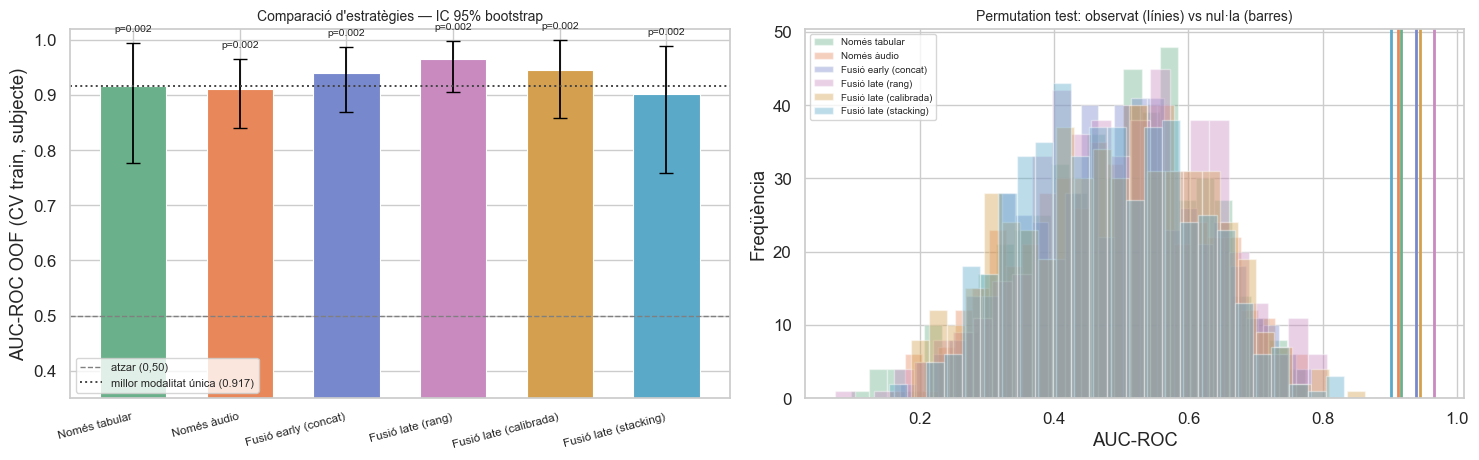

In [21]:
# ── Visualització: AUC-ROC amb IC + distribucions nul·les ───────
_colors = {'tab_only': '#6ab08a', 'aud_only': '#e8885a', 'early': '#7888cc',
           'late_avg': '#c98ac0', 'late_cal': '#d4a04f', 'stack': '#5aa9c9'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.8))

xs   = np.arange(len(STRATEGIES))
vals = [results[s]['roc'] for s in STRATEGIES]
los  = [results[s]['roc'] - results[s]['roc_ci'][0] for s in STRATEGIES]
his  = [results[s]['roc_ci'][1] - results[s]['roc'] for s in STRATEGIES]

ax1.bar(xs, vals, color=[_colors[s] for s in STRATEGIES], width=0.62,
        edgecolor='white', linewidth=0.8)
ax1.errorbar(xs, vals, yerr=[los, his], fmt='none', ecolor='black',
             capsize=5, elinewidth=1.3)
ax1.axhline(0.5, ls='--', color='gray', lw=1, label='atzar (0,50)')
best_single = max(['tab_only', 'aud_only'], key=lambda s: results[s]['roc'])
ax1.axhline(results[best_single]['roc'], ls=':', color='#444', lw=1.4,
            label=f"millor modalitat única ({results[best_single]['roc']:.3f})")
ax1.set_xticks(xs)
ax1.set_xticklabels([LABELS[s] for s in STRATEGIES], rotation=15, ha='right', fontsize=8.5)
ax1.set_ylabel('AUC-ROC OOF (CV train, subjecte)')
ax1.set_ylim(0.35, 1.02)
ax1.set_title('Comparació d\'estratègies — IC 95% bootstrap', fontsize=10)
ax1.legend(fontsize=8)
for x, s in zip(xs, STRATEGIES):
    p = results[s]['p_roc']
    txt = f'p={p:.3f}' if p > 0.001 else 'p<0.001'
    ax1.text(x, results[s]['roc'] + his[xs.tolist().index(x)] + 0.02, txt,
             ha='center', fontsize=7.5)

for s in STRATEGIES:
    ax2.hist(results[s]['null_roc'], bins=25, alpha=0.4, color=_colors[s],
             label=f'{LABELS[s]}')
    ax2.axvline(results[s]['roc'], color=_colors[s], lw=2)
ax2.set_xlabel('AUC-ROC'); ax2.set_ylabel('Freqüència')
ax2.set_title('Permutation test: observat (línies) vs nul·la (barres)', fontsize=10)
ax2.legend(fontsize=7)

plt.tight_layout()
plt.savefig(OUTPUTS / 'hybrid_comparison.pdf', bbox_inches='tight')
plt.show()

### 3.1 Selecció de l'estratègia

El criteri base és el dels blocs 06 i 07: l'AUC-ROC més alt de la CV de subjecte. Però amb 10
positius d'entrenament **els IC de totes les estratègies se solapen** i cap millora de la fusió és estadísticament concloent, de manera que la decisió final incorpora un **criteri de robustesa**: entre estratègies indistingibles (IC 95 % solapats), es prefereix la que **no és transductiva** i és desplegable cas a cas.

La fusió de **rang** obté l'AUC-ROC nominal més alt (0.966), però la fusió **calibrada** (0.945) és estadísticament indistingible —IC [0.86–1.00] vs [0.90–1.00]— i, a diferència del rang, és una funció fixa aplicable a un sol infant. Per això **se selecciona la fusió calibrada com a model final**, assumint una pèrdua nominal de 0.021 d'AUC (dins del soroll) a canvi de robustesa i desplegabilitat. La cel·la següent implementa aquesta regla de manera explícita.

In [30]:
# ── Selecció de l'estratègia (criteri base + robustesa) ──────────
# Base: AUC-ROC de CV (parsimònia com a desempat). Decisió final: entre estratègies
# estadísticament indistingibles (IC 95% solapats), es prefereix la NO transductiva
# i desplegable cas a cas (fusió calibrada) per sobre de la de rang.
COMPLEXITY = {'tab_only': 0, 'aud_only': 0, 'late_avg': 1, 'late_cal': 1, 'stack': 2, 'early': 2}

nominal     = max(STRATEGIES, key=lambda s: (round(results[s]['roc'], 3), -COMPLEXITY[s]))
best_single = max(['tab_only', 'aud_only'], key=lambda s: results[s]['roc'])

# La calibrada és indistingible del millor nominal si el seu IC el solapa
cal_overlaps = results['late_cal']['roc_ci'][1] >= results[nominal]['roc_ci'][0]
if nominal != 'late_cal' and cal_overlaps:
    winner = 'late_cal'
    motiu  = (f"robustesa: indistingible de «{LABELS[nominal]}» (IC solapats) "
              f"però NO transductiva i desplegable cas a cas")
else:
    winner = nominal
    motiu  = "millor AUC-ROC de CV"

delta      = results[winner]['roc'] - results[best_single]['roc']
ci_overlap = results[winner]['roc_ci'][0] <= results[best_single]['roc_ci'][1]

print(f"Millor AUC-ROC nominal : {LABELS[nominal]} ({results[nominal]['roc']:.3f})")
print(f"Estratègia seleccionada: {LABELS[winner]}  [{motiu}]")
print(f"  AUC-ROC = {results[winner]['roc']:.3f}  "
      f"IC95=[{results[winner]['roc_ci'][0]:.2f},{results[winner]['roc_ci'][1]:.2f}]  "
      f"p={results[winner]['p_roc']:.3f}")
print(f"Millor modalitat única : {LABELS[best_single]} (AUC-ROC={results[best_single]['roc']:.3f})")
print(f"Δ (seleccionada − millor única): {delta:+.3f}  |  IC solapats amb la millor única: {ci_overlap}")

Millor AUC-ROC nominal : Fusió late (rang) (0.966)
Estratègia seleccionada: Fusió late (calibrada)  [robustesa: indistingible de «Fusió late (rang)» (IC solapats) però NO transductiva i desplegable cas a cas]
  AUC-ROC = 0.945  IC95=[0.86,1.00]  p=0.002
Millor modalitat única : Només tabular (AUC-ROC=0.917)
Δ (seleccionada − millor única): +0.028  |  IC solapats amb la millor única: True


## 4. Model final i avaluació sobre el hold-out

L'estratègia seleccionada és la **fusió *late* (calibrada)** (AUC-ROC CV = 0.945 [IC 95 %: 0.86, 1.00], p = 0.002). Tot i que la fusió de **rang** obté un AUC-ROC nominalment superior (0.966), la diferència no és estadísticament significativa (IC solapats) i la calibrada té un avantatge decisiu: **no és transductiva**. Cada model base es calibra a una funció fixa, de manera que la predicció d'un infant no depèn de la resta del lot i el model és **desplegable cas a cas** —una propietat necessària per a un cribratge real. El model es reentrena sobre **tot** el conjunt d'entrenament i s'avalua **una sola vegada** sobre el *hold-out*. El llindar es deriva de les prediccions *out-of-fold* calibrades (mai del *hold-out*), maximitzant el **F2 (β = 2)** per l'asimetria clínica (FN ≫ FP). Es reporten les mètriques independents del llindar (AUC-ROC, AUC-PR) i les que en depenen (F1, F2, sensibilitat, especificitat), recordant que amb 3 positius al *hold-out* aquestes darreres són orientatives.

In [31]:
from sklearn.metrics import (roc_curve, auc as sk_auc, precision_recall_curve,
                             ConfusionMatrixDisplay,
                             balanced_accuracy_score)

# ── Prediccions hold-out i llindar derivat de l'OOF (maximitzant F2, β=2) ──
p_hold = predict_holdout(winner, Xt_tr, Xa_tr, y_tr, Xt_ho, Xa_ho)
oof    = results[winner]['oof']

prec_o, rec_o, thr_o = precision_recall_curve(y_tr, oof)
_f2 = 5 * prec_o[:-1] * rec_o[:-1] / np.clip(4 * prec_o[:-1] + rec_o[:-1], 1e-9, None)
thr_star = float(thr_o[int(np.nanargmax(_f2))]) if len(thr_o) else 0.5

y_pred = (p_hold >= thr_star).astype(int)


# Mètriques hold-out via compute_metrics (coherent amb blocs 06/07)
m_ho = compute_metrics(y_ho, p_hold, threshold=thr_star)
roc_ho  = m_ho['roc_auc']
ap_ho   = m_ho['pr_auc']
f1_ho   = m_ho['f1']
f2_ho   = m_ho['f2']
rec_ho  = m_ho['recall']
spec_ho = m_ho['specificity']
bal_ho  = m_ho['balanced_acc']

print(f'Model final: {LABELS[winner]}')
print(f'Llindar* (F2 màx. sobre OOF): {thr_star:.3f}')
print('-' * 48)
print(f'  AUC-ROC       : {roc_ho:.3f}')
print(f'  AUC-PR        : {ap_ho:.3f}')
print(f'  F1            : {f1_ho:.3f}')
print(f'  F2            : {f2_ho:.3f}')
print(f'  Sensibilitat  : {rec_ho:.3f}')
print(f'  Especificitat : {spec_ho:.3f}')
print(f'  Bal. accuracy : {bal_ho:.3f}')
print('\nNota: amb 3 positius al hold-out, les mètriques de llindar són orientatives;')
print("la xifra de referència és l'AUC-ROC de CV amb el seu IC.")


Model final: Fusió late (calibrada)
Llindar* (F2 màx. sobre OOF): 0.265
------------------------------------------------
  AUC-ROC       : 0.974
  AUC-PR        : 0.867
  F1            : 0.800
  F2            : 0.714
  Sensibilitat  : 0.667
  Especificitat : 1.000
  Bal. accuracy : 0.833

Nota: amb 3 positius al hold-out, les mètriques de llindar són orientatives;
la xifra de referència és l'AUC-ROC de CV amb el seu IC.


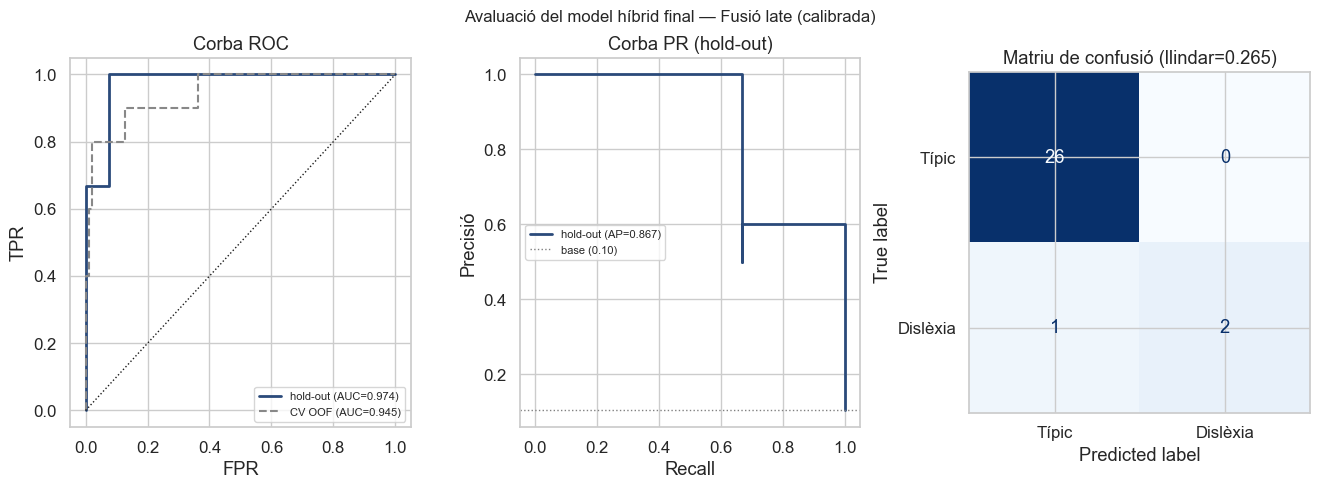

In [32]:
# ── Visualització hold-out: ROC, PR i matriu de confusió ────────
fig = plt.figure(figsize=(16, 4.8))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.32)
ax_roc, ax_pr, ax_cm = (fig.add_subplot(gs[0, i]) for i in range(3))

fpr, tpr, _     = roc_curve(y_ho, p_hold)
fpr_o, tpr_o, _ = roc_curve(y_tr, oof)
ax_roc.plot(fpr, tpr, color='#2a4a7a', lw=2, label=f'hold-out (AUC={sk_auc(fpr,tpr):.3f})')
ax_roc.plot(fpr_o, tpr_o, color='#888', lw=1.5, ls='--', label=f'CV OOF (AUC={sk_auc(fpr_o,tpr_o):.3f})')
ax_roc.plot([0, 1], [0, 1], 'k:', lw=1)
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR'); ax_roc.set_title('Corba ROC'); ax_roc.legend(fontsize=8)

pr_p, pr_r, _ = precision_recall_curve(y_ho, p_hold)
ax_pr.step(pr_r, pr_p, color='#2a4a7a', lw=2, where='post', label=f'hold-out (AP={ap_ho:.3f})')
base = float(np.mean(y_ho))
ax_pr.axhline(base, color='gray', ls=':', lw=1, label=f'base ({base:.2f})')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precisió'); ax_pr.set_title('Corba PR (hold-out)'); ax_pr.legend(fontsize=8)

ConfusionMatrixDisplay.from_predictions(y_ho, y_pred, ax=ax_cm,
    display_labels=['Típic', 'Dislèxia'], colorbar=False, cmap='Blues')
ax_cm.set_title(f'Matriu de confusió (llindar={thr_star:.3f})')

plt.suptitle(f'Avaluació del model híbrid final — {LABELS[winner]}', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUTS / 'hybrid_holdout_eval.pdf', bbox_inches='tight')
plt.show()

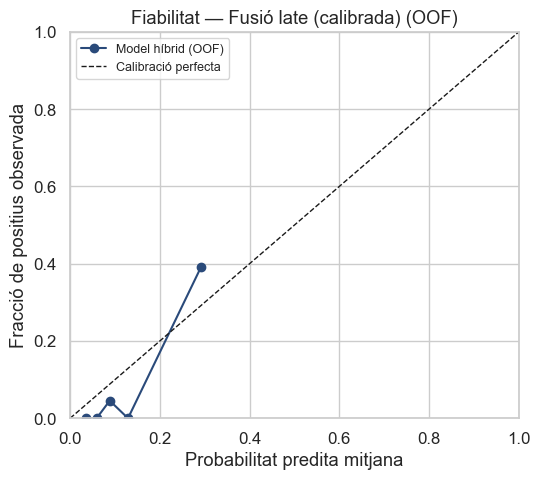

In [33]:
# ── Diagrama de fiabilitat (calibració) de les prediccions OOF ──
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(5.6, 5))
try:
    frac_pos, mean_pred = calibration_curve(y_tr, oof, n_bins=5, strategy='quantile')
    ax.plot(mean_pred, frac_pos, 'o-', color='#2a4a7a', label='Model híbrid (OOF)')
except ValueError:
    print('No es pot estimar la corba de calibració (massa pocs positius en algun bin).')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Calibració perfecta')
ax.set_xlabel('Probabilitat predita mitjana'); ax.set_ylabel('Fracció de positius observada')
ax.set_title(f'Fiabilitat — {LABELS[winner]} (OOF)')
ax.legend(fontsize=9); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(OUTPUTS / 'hybrid_reliability.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# ── Reentrenar el model final sobre TOT el train i desar ─────────
if winner == 'tab_only':
    _ft = make_tab(); _ft.fit(Xt_tr, y_tr)
    final_bundle = {'strategy': winner, 'threshold': thr_star,
                    'feature_names': FEAT_NAMES, 'combination': 'tab_only',
                    'model': _ft}

elif winner == 'aud_only':
    _fa = make_aud(); _fa.fit(Xa_tr, y_tr)
    final_bundle = {'strategy': winner, 'threshold': thr_star,
                    'feature_names': FEAT_NAMES, 'combination': 'aud_only',
                    'model': _fa}

elif winner == 'early':
    Xtr_e = np.hstack([Xt_tr, Xa_tr])
    sc_e  = StandardScaler().fit(Xtr_e)
    lr_e  = LogisticRegression(C=EARLY_C, class_weight='balanced', max_iter=5000)
    lr_e.fit(sc_e.transform(Xtr_e), y_tr)
    final_bundle = {'strategy': winner, 'threshold': thr_star,
                    'feature_names': FEAT_NAMES, 'combination': 'early',
                    'scaler': sc_e, 'lr': lr_e}

elif winner == 'late_avg':
    _ft = make_tab(); _ft.fit(Xt_tr, y_tr)
    _fa = make_aud(); _fa.fit(Xa_tr, y_tr)
    final_bundle = {'strategy': winner, 'threshold': thr_star,
                    'feature_names': FEAT_NAMES, 'combination': 'rank_avg',
                    'tab': _ft, 'aud': _fa}

elif winner == 'late_cal':
    ct = CalibratedClassifierCV(make_tab(), method='sigmoid', cv=5).fit(Xt_tr, y_tr)
    ca = CalibratedClassifierCV(make_aud(), method='sigmoid', cv=5).fit(Xa_tr, y_tr)
    final_bundle = {'strategy': winner, 'threshold': thr_star,
                    'feature_names': FEAT_NAMES, 'combination': 'calibrated_avg',
                    'cal_tab': ct, 'cal_aud': ca}

elif winner == 'stack':
    _ft = make_tab(); _ft.fit(Xt_tr, y_tr)
    _fa = make_aud(); _fa.fit(Xa_tr, y_tr)
    ptr = cross_fit(make_tab, Xt_tr, y_tr, seed=RANDOM_STATE)
    par = cross_fit(make_aud, Xa_tr, y_tr, seed=RANDOM_STATE)
    meta_f = LogisticRegression(C=1.0, class_weight='balanced', max_iter=2000)
    meta_f.fit(np.column_stack([ptr, par]), y_tr)
    final_bundle = {'strategy': winner, 'threshold': thr_star,
                    'feature_names': FEAT_NAMES, 'combination': 'stack',
                    'tab': _ft, 'aud': _fa, 'meta': meta_f}

joblib.dump(final_bundle, OUTPUTS / 'final_hybrid_model.joblib')

summary = dict(
    estrategia=LABELS[winner], clau=winner, llindar=thr_star,
    cv_auc_roc=results[winner]['roc'],
    cv_roc_ci=list(results[winner]['roc_ci']), cv_p_roc=results[winner]['p_roc'],
    holdout=dict(auc_roc=roc_ho, auc_pr=ap_ho, f1=f1_ho, f2=f2_ho,
                 sensibilitat=rec_ho, especificitat=spec_ho, bal_acc=bal_ho,
                 n=int(hold_mask.sum()), positius=int(y_ho.sum())))
with open(OUTPUTS / 'final_hybrid_holdout.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f'Bundle desat: {OUTPUTS / "final_hybrid_model.joblib"}')
print(f'Resum desat : {OUTPUTS / "final_hybrid_holdout.json"}')


Bundle desat: c:\Users\Marçal\OneDrive\Escriptori\TFG\dyslexia-detection\outputs\final_hybrid_model.joblib
Resum desat : c:\Users\Marçal\OneDrive\Escriptori\TFG\dyslexia-detection\outputs\final_hybrid_holdout.json


In [35]:
# ── Resum consolidat del bloc híbrid (convenció CLAUDE.md) ───────
# Mètriques CV del guanyador aplicant el llindar F2 sobre les prediccions OOF
m_cv = compute_metrics(y_tr, results[winner]['oof'], threshold=thr_star)

print('=' * 72)
print('   MODEL HÍBRID — RESUM CONSOLIDAT')
print('=' * 72)

print('\n1) DADES')
print(f'   Subjectes alineats: {len(common)}  '
      f'(train {int(train_mask.sum())} / hold {int(hold_mask.sum())})')
print(f'   Modalitats: tabular ({Xt_tr.shape[1]} dim) + àudio WavLM ({Xa_tr.shape[1]} dim)')

print('\n2) ESTRATÈGIES — AUC-ROC (CV, 5×3 llavors, subjecte)')
for s in STRATEGIES:
    r = results[s]
    star = '  <-- triada' if s == winner else ''
    print(f"   {LABELS[s]:24s}  AUC-ROC={r['roc']:.3f} "
          f"[{r['roc_ci'][0]:.2f},{r['roc_ci'][1]:.2f}]  p={r['p_roc']:.3f}{star}")

print(f'\n3) MODEL FINAL — {LABELS[winner]}')
print(f'   Llindar (F2 màx. sobre OOF): {thr_star:.3f}')
print()
print(f'   {"Mètrica":18s}  {"CV (OOF)":>10s}  {"Hold-out":>10s}')
print(f'   {"-"*18}  {"-"*10}  {"-"*10}')
for met, cv_val, ho_val in [
    ('AUC-ROC',       m_cv['roc_auc'],  roc_ho),
    ('AUC-PR',        m_cv['pr_auc'],   ap_ho),
    ('F1',            m_cv['f1'],       f1_ho),
    ('F2',            m_cv['f2'],       f2_ho),
    ('Sensibilitat',  m_cv['recall'],   rec_ho),
    ('Llindar',       thr_star,         thr_star),
]:
    print(f'   {met:18s}  {cv_val:10.3f}  {ho_val:10.3f}')
print()
print(f'   (Hold-out: n={int(hold_mask.sum())}, positius={int(y_ho.sum())}; '
      'mètriques de llindar orientatives)')
print('=' * 72)


   MODEL HÍBRID — RESUM CONSOLIDAT

1) DADES
   Subjectes alineats: 141  (train 112 / hold 29)
   Modalitats: tabular (22 dim) + àudio WavLM (768 dim)

2) ESTRATÈGIES — AUC-ROC (CV, 5×3 llavors, subjecte)
   Només tabular             AUC-ROC=0.917 [0.78,0.99]  p=0.002
   Només àudio               AUC-ROC=0.912 [0.84,0.97]  p=0.002
   Fusió early (concat)      AUC-ROC=0.939 [0.87,0.99]  p=0.002
   Fusió late (rang)         AUC-ROC=0.966 [0.90,1.00]  p=0.002
   Fusió late (calibrada)    AUC-ROC=0.945 [0.86,1.00]  p=0.002  <-- triada
   Fusió late (stacking)     AUC-ROC=0.902 [0.76,0.99]  p=0.002

3) MODEL FINAL — Fusió late (calibrada)
   Llindar (F2 màx. sobre OOF): 0.265

   Mètrica               CV (OOF)    Hold-out
   ------------------  ----------  ----------
   AUC-ROC                  0.945       0.974
   AUC-PR                   0.789       0.867
   F1                       0.800       0.800
   F2                       0.800       0.714
   Sensibilitat             0.800       0.6

## 5. Conclusió i lectura dels resultats

El model final del bloc híbrid és la **fusió *late* (calibrada)**. La taula de la §3 mostra que les dues fusions *late* superen nominalment la millor modalitat individual (rang 0.966, calibrada 0.945, vs tabular 0.917), però amb 10 positius d'entrenament **tots els IC se solapen**: el guany no és estadísticament concloent. La xifra de referència és l'AUC-ROC de CV amb el seu IC i el p-valor de permutació, confirmada un sol cop pel *hold-out*.

**Per què la calibrada i no el rang.** Totes dues resolen la no-comparabilitat de les escales de probabilitat (~0.43 vs ~0.12), però el rang ho fa de manera *transductiva* —el rang d'un infant depèn del lot que es puntua i el llindar derivat de l'escala de rangs no és transferible cas a cas—, mentre que la calibrada ho fa amb una **funció fixa per modalitat**, desplegable subjecte a subjecte. Que la calibrada (0.945) iguali el rang (0.966) dins del soroll demostra, a més, que el *lift* de la fusió **no és un artefacte del re-escalat per rang**, sinó complementarietat real entre les modalitats: la informació tabular (indicadors lectors explícits) i l'àudio (prosòdia i fluïdesa) aporten senyal parcialment diferent. Es paga una pèrdua nominal de 0.021 d'AUC, no significativa, a canvi de robustesa.

La comparació global amb els blocs anteriors i l'anàlisi d'errors es presenten al Capítol 6 (i al notebook 09).

> **Compatibilitat amb el notebook 09.** El *bundle* desat conté `cal_tab` i `cal_aud`. El 09 ha de
> calcular les probabilitats del *hold-out* amb
> `0.5*(cal_tab.predict_proba(Xt_ho)[:,1] + cal_aud.predict_proba(Xa_ho)[:,1])`, no amb `rank_avg`.